In [157]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

figsize = (4, 2.25)
title_fontsize = 9.2

# Results for PPO, PD Control and Baseline

In [158]:
mean = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
std = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
ra = [10000, 100000, 1000000, 5000000]

# read from csv
for method in mean.keys():
    for ra_elem in ra:
            if method == "baseline":
                path = f"res/{method}_ra{ra_elem}.csv"
            else:
                path = f"res/{method}_ra{ra_elem}_nusselt.csv"
            try:
                df = pandas.read_csv(path)

                # mean per episode
                df = df.groupby('episode').mean()
                mean[method].append(df["nusselt"].mean())
                std[method].append(df["nusselt"].std())
            except Exception as e:
                mean[method].append(0)
                std[method].append(0)

# # compute percentage
mean_percent = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
std_percent = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
for idx in range(len(mean["baseline"])):
    for method in mean.keys():
        b = mean["baseline"][idx]
        mean_percent[method].append(100 - (100 * mean[method][idx] / b))
        std_percent[method].append(100 * std[method][idx] / b)

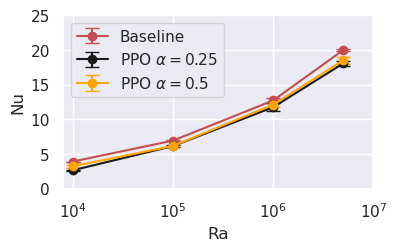

In [159]:
# plot
plt.figure(figsize=figsize)
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(0, 25)
#plt.yscale("log")
plt.ylabel("Nu")

# plot data
plt.errorbar(ra, mean["baseline"], std["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean["PPO_rs25"], std["PPO_rs25"], linestyle="-", marker='o', color='k', capsize=5, label=r"PPO $\alpha=0.25$")
plt.errorbar(ra, mean["PPO_rs50"], std["PPO_rs50"], linestyle="-", marker='o', color='orange', capsize=5, label=r"PPO $\alpha=0.5$")
plt.legend()

plt.savefig("paperfigures/nusselt.svg", format="svg", bbox_inches="tight")
plt.show()

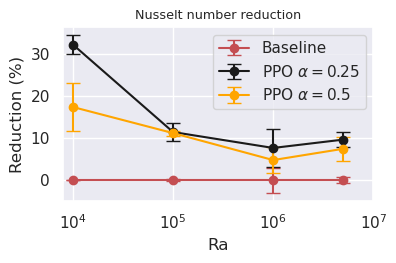

In [160]:
# plot
plt.figure(figsize=figsize)
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
# plt.ylim(-5, 40)
plt.ylabel("Reduction (%)")
plt.title("Nusselt number reduction", fontsize=title_fontsize)

# plot data
plt.errorbar(ra, mean_percent["baseline"], std_percent["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean_percent["PPO_rs25"], std_percent["PPO_rs25"], linestyle="-", marker='o', color='k', capsize=5, label=r"PPO $\alpha=0.25$")
plt.errorbar(ra, mean_percent["PPO_rs50"], std_percent["PPO_rs50"], linestyle="-", marker='o', color='orange', capsize=5, label=r"PPO $\alpha=0.5$")
plt.legend()

plt.savefig("paperfigures/nusselt_reduction_percentage.svg", format="svg", bbox_inches="tight")
plt.show()

In [161]:
# What is the percentage of episodes that reach a one cell state?
# read from csv
csv_files_nors = [
        "PPO_rs0_ra10000_cell_dist.csv",
        "PPO_rs0_ra100000_cell_dist.csv",
        "PPO_rs0_ra1000000_cell_dist.csv",
        "PPO_rs0_ra5000000_cell_dist.csv"
        ]

csv_files_rs = [
     "PPO_rs25_ra10000_cell_dist.csv",
     "PPO_rs25_ra100000_cell_dist.csv",
     "PPO_rs50_ra1000000_cell_dist.csv",
     "PPO_rs50_ra5000000_cell_dist.csv"
     ]
ra = [10000, 100000, 1000000, 5000000]
percentages_one_cell_rs = []
thres = 0.8
nr_episodes = 20

def calculate_percentage(csv_files, thres, nr_episodes):
    percentages_one_cell_rs = []
    for i in range(len(csv_files)):
        path = f"res/{csv_files[i]}"
        try:
            df = pandas.read_csv(path)
            episodes_one_cell = 0
            for idx_group, episode_df in df.groupby('episode'):
                # if the episode already starts in one cell, we exclude it from the count
                if (episode_df.cell_dist.iloc[0:20] == 0).sum() >= 16:
                    continue
                # strategy: If among the last 10% of the episode, there is at least 80% with a cell distance of 0, then we consider it a one cell state.
                last_10_percent = int(0.1 * len(episode_df))
                episode_df.iloc[-last_10_percent:]
                one_cell_state = episode_df.iloc[-last_10_percent:].cell_dist == 0
                if one_cell_state.sum() / last_10_percent >= thres:
                    episodes_one_cell += 1
            percentages_one_cell_rs.append(episodes_one_cell / nr_episodes) 
            # print(f"Percentage of episodes that reach one cell state: {episodes_one_cell / nr_episodes}")
        except Exception as e:
            print(e)
    return percentages_one_cell_rs

percentages_one_cell_rs = calculate_percentage(csv_files_rs, thres, nr_episodes)
percentages_one_cell_nors = calculate_percentage(csv_files_nors, thres, nr_episodes)

In [162]:
percentages_one_cell_nors

[0.6, 0.1, 0.0, 0.0]

In [163]:
np.array(percentages_one_cell_rs) * 100 

array([100., 100.,  20.,   0.])

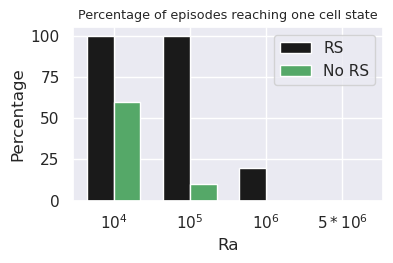

In [164]:
# Make a simple bar chart to show the result (with reward shaping and without reward shaping)
# Sample data
categories = [r'$10^4$', r'$10^5$', r'$10^6$', r'$5*10^6$']
values_group1 = np.array(percentages_one_cell_rs) * 100
values_group2 = np.array(percentages_one_cell_nors) * 100

x = np.arange(len(categories))  # x locations for groups
width = 0.35  # Width of bars

fig, ax = plt.subplots(figsize=figsize)

# Plot bars for both groups
bars1 = ax.bar(x - width/2, values_group1, width, color='k', label='RS')
bars2 = ax.bar(x + width/2, values_group2, width, color='g', label='No RS')

# Labels and title
ax.set_xlabel("Ra")
ax.set_ylabel("Percentage")
ax.set_title("Percentage of episodes reaching one cell state", fontsize=title_fontsize)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.savefig("paperfigures/percentage_eps_onecell.svg", format="svg", bbox_inches="tight")

# Show the plot
plt.show()

In [165]:
# Figure showing the reduction in standard deviation of the Nusselt number for different Ra values
# 60 / 1.5 = 40 (40 rows amounts to 60 simulation seconds)
window_std = 40
# compute standard deviations
csv_files_nors = [
        "ppo_ra10000.csv",
        "ppo_ra100000.csv",
        "ppo_ra1000000.csv",
        "ppo_ra5000000.csv"
        ]
csv_files_rs = [
     "PPO_rs25_ra10000_nusselt.csv",
     "PPO_rs25_ra100000_nusselt.csv",
     "PPO_rs50_ra1000000_nusselt.csv",
     "PPO_rs50_ra5000000_nusselt.csv"
     ]
ra = [10000, 100000, 1000000, 5000000]
nr_episodes = 20

def calculate_std(csv_files, nr_episodes):
    stds = {}
    for file in csv_files:
        stds[file] = []
    for i in range(len(csv_files)):
        path = f"res/{csv_files[i]}"
        try:
            df = pandas.read_csv(path)
            for idx_group, episode_df in df.groupby('episode'):
                std_begin = episode_df.iloc[:window_std].nusselt.std()
                std_end = episode_df.iloc[-window_std:].nusselt.std()
                reduction_std = 100 - std_end / std_begin * 100
                stds[csv_files[i]].append(reduction_std)
        except Exception as e:
            print(e)
    return stds

stds_rs = calculate_std(csv_files_rs, nr_episodes)
stds_nors = calculate_std(csv_files_nors, nr_episodes)

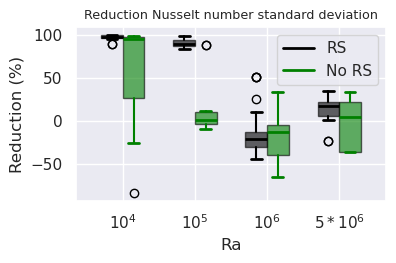

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (replace with actual values)
data = [
    [stds_rs["PPO_rs25_ra10000_nusselt.csv"], 
     stds_nors["ppo_ra10000.csv"]],  # Ra = 10^4

    [stds_rs["PPO_rs25_ra100000_nusselt.csv"],
     stds_nors["ppo_ra100000.csv"]],  # Ra = 10^5

    [stds_rs["PPO_rs50_ra1000000_nusselt.csv"],
        stds_nors["ppo_ra1000000.csv"]],  # Ra = 10^6

    [stds_rs["PPO_rs50_ra5000000_nusselt.csv"],
        stds_nors["ppo_ra5000000.csv"]]  # Ra = 5*10^6
]

categories = [r'$10^4$', r'$10^5$', r'$10^6$', r'$5*10^6$']  # Rayleigh numbers
group_labels = ['RS', 'No RS']  # Updated legend labels

# Define colors and styles
colors = ['black', 'green']
linestyles = ['solid', 'dashed']

# Create figure
fig, ax = plt.subplots(figsize=figsize)

# Set positions for grouping
num_groups = len(categories)
num_subgroups = len(data[0])
positions = np.arange(num_groups)  # Base positions
width = 0.3  # Width of each box

# Flatten the data and positions
all_data = [d for group in data for d in group]
all_positions = [p + (i - (num_subgroups - 1)/2) * width for p in positions for i in range(num_subgroups)]

# Create boxplot with different styles
boxplots = ax.boxplot(
    all_data, 
    positions=all_positions, 
    widths=width, 
    patch_artist=True  # Enables color filling
)

# Apply colors and styles
for i, (box, median) in enumerate(zip(boxplots['boxes'], boxplots['medians'])):
    group_index = i % num_subgroups  # 0 or 1
    color = colors[group_index]
    
    # Set box color
    box.set(facecolor=color, alpha=0.6, edgecolor='black')
    
    # Set whiskers and caps color (fixing the issue)
    for whisker in boxplots['whiskers'][2*i:2*i+2]:  # Both whiskers for the box
        whisker.set(color=color, linewidth=1.5)
        
    for cap in boxplots['caps'][2*i:2*i+2]:  # Both caps for the box
        cap.set(color=color, linewidth=2)
    
    # Set median color
    median.set(color=color, linewidth=2)

# Adjust x-axis
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_xlabel("Ra")
ax.set_ylabel("Reduction (%)")
ax.set_title("Reduction Nusselt number standard deviation", fontsize=title_fontsize)

# Create legend manually
handles = [
    plt.Line2D([0], [0], color=colors[i], linewidth=2, label=group_labels[i])
    for i in range(num_subgroups)
]
ax.legend(handles=handles, title="")

plt.savefig("paperfigures/reduction_std_RS_NoRS.svg", format="svg", bbox_inches="tight")

# Show plot
plt.show()

In [167]:
stds_rs["PPO_rs25_ra100000_nusselt.csv"]

[89.73640822415733,
 87.40158415097969,
 84.61716052249014,
 98.4161243863336,
 84.61716052249014,
 90.6272425416337,
 88.21579217494673,
 84.26485926992258,
 97.25116633362092,
 97.25116633362092,
 88.21579217494673,
 90.6272425416337,
 97.25116633362092,
 94.02860196984962,
 97.25116633362092,
 88.21579217494673,
 90.6272425416337,
 87.40158415097969,
 87.40158415097969,
 94.02860196984962]

In [168]:
print(df)

           nusselt    time
episode                   
0        19.807690  150.75
1        19.807690  150.75
2        18.304386  150.75
3        18.157676  150.75
4        18.466661  150.75
5        19.568975  150.75
6        18.466661  150.75
7        18.028538  150.75
8        18.567746  150.75
9        18.062249  150.75
10       18.567746  150.75
11       18.304386  150.75
12       18.073359  150.75
13       18.073359  150.75
14       18.028538  150.75
15       18.157676  150.75
16       18.073359  150.75
17       18.243708  150.75
18       18.466661  150.75
19       18.466661  150.75


In [169]:
120 / 100 * 100

120.0

In [170]:
# Last plot: time to reach one cell state
# Approach: What is the first window of 10% of the episode where the cell distance is 0 for at least 80% of the time?
# This makes sense only for ra=10000 and ra=100000
csv_files_rs = ["PPO_rs25_ra10000_cell_dist.csv", "PPO_rs25_ra100000_cell_dist.csv"]
csv_files_nors = ["PPO_rs0_ra10000_cell_dist.csv", "PPO_rs0_ra100000_cell_dist.csv"]
ra = [10000, 100000]   
thres = 0.8


def calculate_times_to_reach_one_cell(csv_files, thres):
    times_to_reach_one_cell = {}
    for file in csv_files:
        times_to_reach_one_cell[file] = []
    for file in csv_files:
        path = f"res/{file}"
        try:
            df = pandas.read_csv(path)
            for idx_group, episode_df in df.groupby('episode'):
                # first check if the episode reaches a one cell state
                last_10_percent = int(0.1 * len(episode_df))
                episode_df.iloc[-last_10_percent:]
                one_cell_state = episode_df.iloc[-last_10_percent:].cell_dist == 0
                if one_cell_state.sum() / last_10_percent < thres:
                    # print("episode does not go to a one cell state")
                    continue
                # so we only continue below if the episode reaches a one cell state, and we then check when it reaches it for the first time
                last_10_percent = int(0.1 * len(episode_df))
                for idx in range(0, len(episode_df) - last_10_percent):
                    subdf = episode_df.iloc[idx:idx+last_10_percent]
                    one_cell_state = subdf[subdf['cell_dist'] == 0]
                    if one_cell_state.shape[0] / last_10_percent >= thres:
                        times_to_reach_one_cell[file].append(one_cell_state.iloc[0].time)
                        break
        except Exception as e:
            print("An error occurred: ", e)
    return times_to_reach_one_cell

times_to_reach_one_cell_rs = calculate_times_to_reach_one_cell(csv_files_rs, thres)
times_to_reach_one_cell_nors = calculate_times_to_reach_one_cell(csv_files_nors, thres)

In [171]:
times_to_reach_one_cell_nors

{'PPO_rs0_ra10000_cell_dist.csv': [19.5,
  66.0,
  40.5,
  40.5,
  40.5,
  66.0,
  40.5,
  82.5,
  45.0,
  19.5,
  54.0,
  54.0],
 'PPO_rs0_ra100000_cell_dist.csv': [190.5, 190.5]}

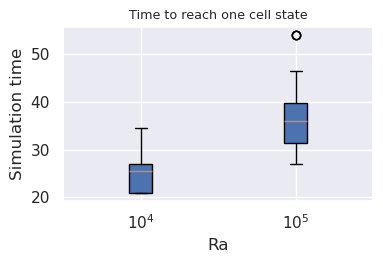

In [172]:
# Sample data for three categories
data = [times_to_reach_one_cell_rs["PPO_rs25_ra10000_cell_dist.csv"], times_to_reach_one_cell_rs["PPO_rs25_ra100000_cell_dist.csv"]]

categories = [r'$10^4$', r'$10^5$']

# Create the boxplot
fig, ax = plt.subplots(figsize=figsize)
ax.boxplot(data, labels=categories, patch_artist=True)

# Labels and title
ax.set_xlabel("Ra")
ax.set_ylabel("Simulation time")
ax.set_title("Time to reach one cell state", fontsize=title_fontsize)

plt.savefig("paperfigures/time_eps_onecell.svg", format="svg", bbox_inches="tight")

# Show the plot
plt.show()

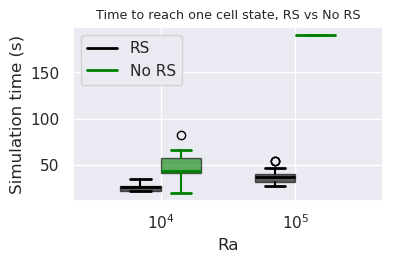

In [173]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (replace with actual values)
data = [
    [times_to_reach_one_cell_rs["PPO_rs25_ra10000_cell_dist.csv"], 
     times_to_reach_one_cell_nors["PPO_rs0_ra10000_cell_dist.csv"]],  # Ra = 10^4
    
    [times_to_reach_one_cell_rs["PPO_rs25_ra100000_cell_dist.csv"], 
     times_to_reach_one_cell_nors["PPO_rs0_ra100000_cell_dist.csv"]]  # Ra = 10^5
]

categories = [r'$10^4$', r'$10^5$']  # Rayleigh numbers
group_labels = ['RS', 'No RS']  # Updated legend labels

# Define colors and styles
colors = ['black', 'green']
linestyles = ['solid', 'dashed']

# Create figure
fig, ax = plt.subplots(figsize=figsize)

# Set positions for grouping
num_groups = len(categories)
num_subgroups = len(data[0])
positions = np.arange(num_groups)  # Base positions
width = 0.3  # Width of each box

# Flatten the data and positions
all_data = [d for group in data for d in group]
all_positions = [p + (i - (num_subgroups - 1)/2) * width for p in positions for i in range(num_subgroups)]

# Create boxplot with different styles
boxplots = ax.boxplot(
    all_data, 
    positions=all_positions, 
    widths=width, 
    patch_artist=True  # Enables color filling
)

# Apply colors and styles
for i, (box, median) in enumerate(zip(boxplots['boxes'], boxplots['medians'])):
    group_index = i % num_subgroups  # 0 or 1
    color = colors[group_index]
    
    # Set box color
    box.set(facecolor=color, alpha=0.6, edgecolor='black')
    
    # Set whiskers and caps color (fixing the issue)
    for whisker in boxplots['whiskers'][2*i:2*i+2]:  # Both whiskers for the box
        whisker.set(color=color, linewidth=1.5)
        
    for cap in boxplots['caps'][2*i:2*i+2]:  # Both caps for the box
        cap.set(color=color, linewidth=2)
    
    # Set median color
    median.set(color=color, linewidth=2)

# Adjust x-axis
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_xlabel("Ra")
ax.set_ylabel("Simulation time (s)")
ax.set_title("Time to reach one cell state, RS vs No RS", fontsize=title_fontsize)

# Create legend manually
handles = [
    plt.Line2D([0], [0], color=colors[i], linewidth=2, label=group_labels[i])
    for i in range(num_subgroups)
]
ax.legend(handles=handles, title="")

plt.savefig("paperfigures/time_eps_onecell.svg", format="svg", bbox_inches="tight")

# Show plot
plt.show()